# 🖼️ Laboratorio: Procesamiento Digital de Imágenes
## Capítulos 1 & 2 — Fundamentos y Álgebra Lineal aplicada

> **Basado en:** González & Woods, *Digital Image Processing*, 3ra Ed.  
> **Duración estimada:** 2 horas  
> **Nivel:** 5to Ciclo

---

### 🗺️ Mapa del laboratorio

| # | Sección | Tiempo aprox. | Temas clave |
|---|---------|---------------|-------------|
| 1 | Imágenes como Matrices | 20 min | Álgebra lineal, representación |
| 2 | Muestreo y Cuantización | 20 min | Resolución, niveles de gris |
| 3 | Percepción y Relaciones entre Píxeles | 20 min | Vecindad, conectividad |
| 4 | Operaciones Básicas con Álgebra Lineal | 25 min | Negativo, brillo, umbral, mezcla |
| 5 | 🎮 Modo Libre — Tu propia imagen | 35 min | Experimentación guiada |

---
### ⚙️ Setup — Ejecuta esta celda primero

In [1]:
# ============================================================
#  SETUP — Importaciones y configuración global
#  Ejecuta esta celda antes de cualquier otra.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from PIL import Image, ImageFilter
import warnings, io, os, urllib.request
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'figure.titlesize': 14,
    'axes.titlesize':   12,
    'axes.titlecolor':  '#58a6ff',
})

# Función utilitaria para mostrar imágenes con título
def mostrar(imgs, titulos, cmap='gray', figsize=None, suptitle=None):
    """Muestra una lista de imágenes lado a lado."""
    n = len(imgs)
    fs = figsize or (5 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=fs)
    if n == 1:
        axes = [axes]
    for ax, img, tit in zip(axes, imgs, titulos):
        cm = cmap if img.ndim == 2 else None
        ax.imshow(img, cmap=cm, vmin=0, vmax=255)
        ax.set_title(tit, fontsize=11)
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, color='#58a6ff', y=1.02)
    plt.tight_layout()
    plt.show()

print('✅  Setup completado. ¡Listos para procesar imágenes!')
print(f'   NumPy  {np.__version__}')
print(f'   Pillow {Image.__version__}')
print(f'   Matplotlib {plt.matplotlib.__version__}')

✅  Setup completado. ¡Listos para procesar imágenes!
   NumPy  2.0.2
   Pillow 11.3.0
   Matplotlib 3.10.0


---
## 📐 Sección 1 — Imágenes como Matrices
### *"Una imagen no es más que álgebra lineal con píxeles"*

En matemáticas, una **imagen en escala de grises** es simplemente una matriz $\mathbf{F} \in \mathbb{Z}^{M \times N}$ donde cada elemento $f_{ij}$ representa la intensidad del píxel en la fila $i$, columna $j$:

$$\mathbf{F} = \begin{pmatrix} f_{00} & f_{01} & \cdots & f_{0,N-1} \\ f_{10} & f_{11} & \cdots & f_{1,N-1} \\ \vdots & & \ddots & \vdots \\ f_{M-1,0} & & \cdots & f_{M-1,N-1} \end{pmatrix} \quad f_{ij} \in [0, 255]$$

Una **imagen a color (RGB)** es un **tensor** $\mathbf{T} \in \mathbb{Z}^{M \times N \times 3}$ — tres matrices apiladas (canales R, G, B).

---
### 🧪 Ejercicio 1.1 — Creando imágenes desde cero con NumPy

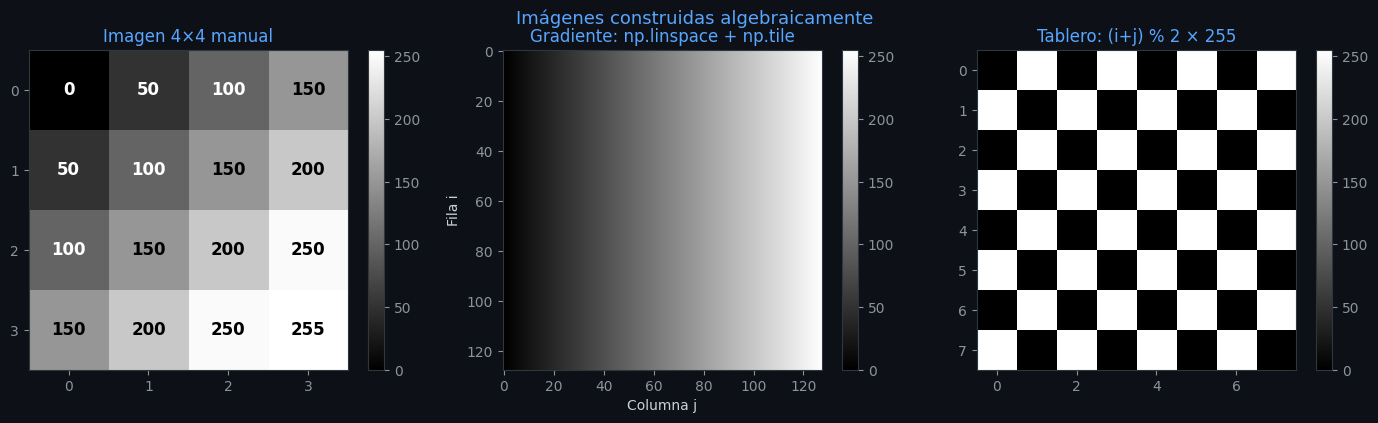

Forma de F_manual   : (4, 4)   → 4 filas × 4 cols
Forma de F_gradiente: (128, 128) → tensor 2D (escala de grises)
Dtype               : uint8  → enteros sin signo 8 bits (0-255)


In [2]:
# ============================================================
#  EJERCICIO 1.1 — Construir imágenes manualmente como matrices
# ============================================================

# --- Imagen 4×4 definida a mano ---
F_manual = np.array([
    [  0,  50, 100, 150],
    [ 50, 100, 150, 200],
    [100, 150, 200, 250],
    [150, 200, 250, 255]
], dtype=np.uint8)

# --- Imagen de gradiente 128×128 ---
# np.linspace genera 128 valores igualmente espaciados entre 0 y 255
fila = np.linspace(0, 255, 128)          # Vector fila: [0, 2, 4, ..., 255]
F_gradiente = np.tile(fila, (128, 1))    # Repite el vector 128 veces → matriz
F_gradiente = F_gradiente.astype(np.uint8)

# --- Tablero de ajedrez usando operaciones matriciales ---
# Truco algebraico: si (i+j) es par → negro, si es impar → blanco
i_idx, j_idx = np.mgrid[0:8, 0:8]       # Índices de fila y columna
F_ajedrez = ((i_idx + j_idx) % 2) * 255
F_ajedrez = F_ajedrez.astype(np.uint8)

# --- Visualizamos ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(F_manual, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagen 4×4 manual')
# Mostrar los valores dentro de cada celda
for i in range(4):
    for j in range(4):
        color = 'black' if F_manual[i,j] > 127 else 'white'
        axes[0].text(j, i, F_manual[i,j], ha='center', va='center',
                     fontsize=12, fontweight='bold', color=color)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(F_gradiente, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Gradiente: np.linspace + np.tile')
axes[1].set_xlabel('Columna j')
axes[1].set_ylabel('Fila i')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(F_ajedrez, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Tablero: (i+j) % 2 × 255')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Imágenes construidas algebraicamente', fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

print(f'Forma de F_manual   : {F_manual.shape}   → {F_manual.shape[0]} filas × {F_manual.shape[1]} cols')
print(f'Forma de F_gradiente: {F_gradiente.shape} → tensor 2D (escala de grises)')
print(f'Dtype               : {F_gradiente.dtype}  → enteros sin signo 8 bits (0-255)')

### 🧪 Ejercicio 1.2 — Propiedades matriciales de una imagen real

Vamos a cargar una imagen de muestra y explorar sus propiedades algebraicas: rango, norma, traza, y los tres canales RGB como matrices independientes.

  ANÁLISIS ALGEBRAICO DE LA IMAGEN
  Forma del tensor color : (200, 300, 3)  (M×N×C)
  Forma matriz gris      : (200, 300)   (M×N)
  Tipo de dato           : uint8
  Total de píxeles       : 60,000 = 200×300
  Memoria aprox          : 175.8 KB

  Intensidad mínima      : 38.0
  Intensidad máxima      : 199.0
  Media (μ)              : 115.22
  Desv. estándar (σ)     : 26.54
  Norma de Frobenius ‖F‖ : 28962.2
  Traza  tr(F)           : 20235.0  (suma diagonal)


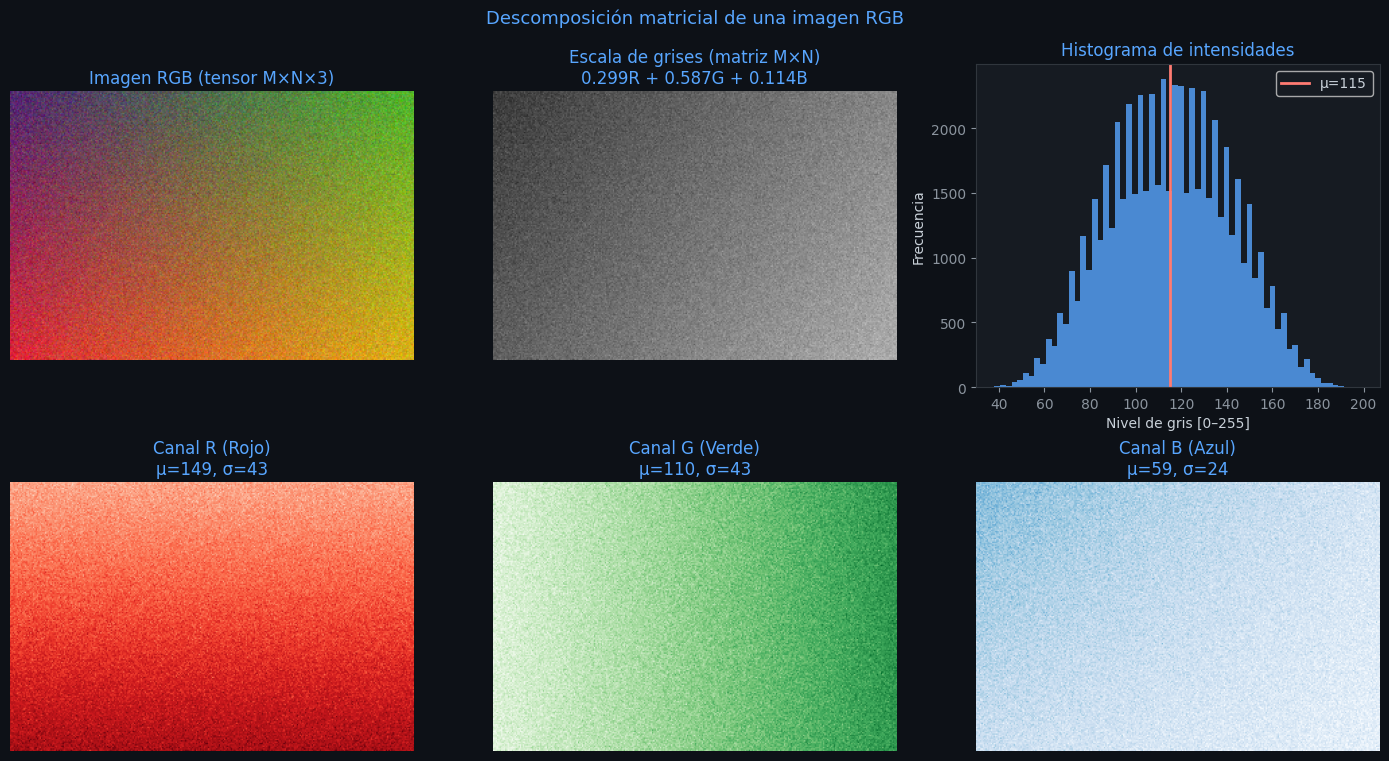

In [3]:
# ============================================================
#  EJERCICIO 1.2 — Propiedades algebraicas de una imagen
# ============================================================

# Generamos una imagen de muestra sintética (paisaje de colores)
# Si tienes conexión a internet puedes reemplazar esto con:
#   img = np.array(Image.open('tu_imagen.jpg'))

np.random.seed(42)
H, W = 200, 300

# Construimos canales con gradientes + ruido → simula una foto
R = np.outer(np.linspace(80, 220, H), np.ones(W)) + np.random.normal(0, 15, (H, W))
G = np.outer(np.ones(H), np.linspace(40, 180, W)) + np.random.normal(0, 15, (H, W))
B = np.outer(np.linspace(120, 60, H), np.linspace(200, 80, W)/255) * 1.2 + np.random.normal(0, 15, (H, W))

# Clipeamos al rango válido [0, 255]
R = np.clip(R, 0, 255).astype(np.uint8)
G = np.clip(G, 0, 255).astype(np.uint8)
B = np.clip(B, 0, 255).astype(np.uint8)

# Apilamos los canales → tensor M×N×3
img_color = np.stack([R, G, B], axis=2)

# Convertir a escala de grises usando la fórmula ITU-R BT.601
# NO es un simple promedio — los canales tienen pesos diferentes
# porque el ojo humano es más sensible al verde
img_gris = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

# ── Análisis algebraico ──
print('='*55)
print('  ANÁLISIS ALGEBRAICO DE LA IMAGEN')
print('='*55)
print(f'  Forma del tensor color : {img_color.shape}  (M×N×C)')
print(f'  Forma matriz gris      : {img_gris.shape}   (M×N)')
print(f'  Tipo de dato           : {img_color.dtype}')
print(f'  Total de píxeles       : {H*W:,} = {H}×{W}')
print(f'  Memoria aprox          : {img_color.nbytes/1024:.1f} KB')
print()
F = img_gris.astype(np.float64)
print(f'  Intensidad mínima      : {F.min():.1f}')
print(f'  Intensidad máxima      : {F.max():.1f}')
print(f'  Media (μ)              : {F.mean():.2f}')
print(f'  Desv. estándar (σ)     : {F.std():.2f}')
print(f'  Norma de Frobenius ‖F‖ : {np.linalg.norm(F):.1f}')
print(f'  Traza  tr(F)           : {np.trace(F):.1f}  (suma diagonal)')
print('='*55)

# ── Visualización ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0,0].imshow(img_color)
axes[0,0].set_title('Imagen RGB (tensor M×N×3)')
axes[0,0].axis('off')

axes[0,1].imshow(img_gris, cmap='gray', vmin=0, vmax=255)
axes[0,1].set_title('Escala de grises (matriz M×N)\n0.299R + 0.587G + 0.114B')
axes[0,1].axis('off')

# Histograma
axes[0,2].hist(img_gris.ravel(), bins=64, color='#58a6ff', alpha=0.8, edgecolor='none')
axes[0,2].set_title('Histograma de intensidades')
axes[0,2].set_xlabel('Nivel de gris [0–255]')
axes[0,2].set_ylabel('Frecuencia')
axes[0,2].axvline(img_gris.mean(), color='#ff7b72', lw=2, label=f'μ={img_gris.mean():.0f}')
axes[0,2].legend()

# Los tres canales por separado
channel_info = [('Canal R (Rojo)', R, 'Reds'), ('Canal G (Verde)', G, 'Greens'), ('Canal B (Azul)', B, 'Blues')]
for ax, (titulo, canal, cmap_name) in zip(axes[1], channel_info):
    ax.imshow(canal, cmap=cmap_name, vmin=0, vmax=255)
    ax.set_title(f'{titulo}\nμ={canal.mean():.0f}, σ={canal.std():.0f}')
    ax.axis('off')

plt.suptitle('Descomposición matricial de una imagen RGB', fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

### 💡 Reflexión 1 — Responde en la celda siguiente

1. ¿Por qué el canal verde tiene el coeficiente más alto (0.587) en la fórmula de escala de grises?
2. Si una imagen es de 1920×1080 a color (RGB), ¿cuántos bytes ocupa sin compresión?
3. ¿Qué representa la **norma de Frobenius** de una imagen en términos visuales?

In [ ]:
# ✏️  Escribe tus respuestas aquí como comentarios o strings

respuesta_1 = """
Escribe tu respuesta aquí...
"""

respuesta_2 = """
# Pista: bytes = filas × columnas × canales × bytes_por_canal
filas, cols, canales = 1080, 1920, 3
bytes_total = filas * cols * canales
print(f'Bytes sin compresión: {bytes_total:,}')
print(f'En MB: {bytes_total / (1024**2):.2f} MB')
"""

exec(respuesta_2)  # Ejecuta el cálculo de la pregunta 2

respuesta_3 = """
Escribe tu respuesta aquí...
"""
print('Respuesta 1:', respuesta_1)
print('Respuesta 3:', respuesta_3)

---
## 🔢 Sección 2 — Muestreo y Cuantización

Recordemos las definiciones formales:

**Muestreo** — Proceso de convertir una función continua $f(x,y)$ a una función discreta $f[m,n]$. Define la **resolución espacial** (cuántos píxeles).

**Cuantización** — Proceso de mapear valores continuos de intensidad a un conjunto finito de enteros. Define la **resolución de amplitud** (cuántos niveles de gris).

$$L = 2^k \quad \text{(niveles de gris con } k \text{ bits)}$$

| k (bits) | L (niveles) | Tamaño imagen 256×256 |
|----------|------------|----------------------|
| 1 | 2 | 8 KB |
| 2 | 4 | 16 KB |
| 4 | 16 | 32 KB |
| 8 | 256 | 64 KB |

---
### 🧪 Ejercicio 2.1 — Efecto de la resolución espacial (Muestreo)

In [ ]:
# ============================================================
#  EJERCICIO 2.1 — Reducción de resolución espacial
# ============================================================

# Creamos una imagen de referencia: cara smiley sintética
size = 256
F_original = np.zeros((size, size), dtype=np.uint8)

# Fondo gris
F_original[:] = 200

# Cara (círculo grande)
yy, xx = np.ogrid[:size, :size]
centro = size // 2
F_original[((yy-centro)**2 + (xx-centro)**2) < (100)**2] = 240

# Ojos
F_original[((yy-90)**2 + (xx-85)**2) < 15**2] = 30
F_original[((yy-90)**2 + (xx-171)**2) < 15**2] = 30

# Sonrisa (arco usando condición algebraica)
for col in range(70, 187):
    fila = int(centro + 30 + 25 * np.sin(np.pi * (col - 70) / 116))
    if 0 <= fila < size:
        F_original[fila-4:fila+4, col-4:col+4] = 30

# Nariz
F_original[((yy-128)**2 + (xx-128)**2) < 8**2] = 80

# ── Reducción de resolución (subsampling) ──
resoluciones = [256, 128, 64, 32, 16, 8]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, res in zip(axes, resoluciones):
    # Reducir y ampliar de vuelta al tamaño original para comparar
    img_pil = Image.fromarray(F_original)
    img_small = img_pil.resize((res, res), Image.NEAREST)
    img_back  = img_small.resize((size, size), Image.NEAREST)
    img_np    = np.array(img_back)
    
    ax.imshow(img_np, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{res}×{res} píxeles\n({res*res:,} píxeles totales)')
    ax.axis('off')

plt.suptitle('Efecto del muestreo: misma imagen, diferente resolución espacial',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

print('📌 Observación: A menor resolución, se pierde detalle espacial.')
print('   Este fenómeno se llama ALIASING cuando hay sub-muestreo.')

### 🧪 Ejercicio 2.2 — Efecto de la cuantización (niveles de gris)

La cuantización reduce el número de niveles de intensidad. La fórmula para cuantizar a $k$ bits es:

$$f_q[m,n] = \left\lfloor \frac{f[m,n]}{256 / 2^k} \right\rfloor \cdot \frac{256}{2^k}$$

In [ ]:
# ============================================================
#  EJERCICIO 2.2 — Reducción de niveles de cuantización
# ============================================================

def cuantizar(imagen, bits):
    """
    Reduce la imagen a 2^bits niveles de gris.
    Fórmula: floor(f / paso) * paso   donde paso = 256 / 2^bits
    """
    niveles = 2 ** bits
    paso = 256 // niveles
    img_q = (imagen.astype(np.float32) // paso) * paso
    return np.clip(img_q, 0, 255).astype(np.uint8)

bits_list = [8, 6, 4, 3, 2, 1]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, k in zip(axes, bits_list):
    img_q = cuantizar(F_original, k)
    niveles = 2**k
    ax.imshow(img_q, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{k} bits → {niveles} niveles de gris\nL = 2^{k} = {niveles}')
    ax.axis('off')

plt.suptitle('Efecto de la cuantización: misma resolución, distintos niveles de gris',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

# ── Análisis cuantitativo ──
print('\n📊 Error cuadrático medio (MSE) vs imagen original de 8 bits:')
print(f'   {"Bits":>5} | {"Niveles":>8} | {"MSE":>10} | {"PSNR (dB)":>10}')
print('   ' + '-'*43)
for k in [8, 6, 4, 3, 2, 1]:
    img_q = cuantizar(F_original, k).astype(np.float64)
    orig  = F_original.astype(np.float64)
    mse   = np.mean((orig - img_q)**2)
    psnr  = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    print(f'   {k:>5} | {2**k:>8} | {mse:>10.2f} | {psnr:>10.2f}')

### 🧪 Ejercicio 2.3 — ¡Tú defines los parámetros! (modifica los valores)

Experimenta cambiando `BITS` y `RESOLUCION` y observa el efecto combinado.

In [ ]:
# ============================================================
#  ✏️  MODIFICA ESTOS VALORES Y RE-EJECUTA
# ============================================================

BITS       = 3    # ← Cambia este valor (1 a 8)
RESOLUCION = 64   # ← Cambia este valor (8, 16, 32, 64, 128, 256)

# ── Aplicamos ambas degradaciones ──
img_pil    = Image.fromarray(F_original)
img_small  = img_pil.resize((RESOLUCION, RESOLUCION), Image.NEAREST)
img_back   = img_small.resize((256, 256), Image.NEAREST)
img_res    = np.array(img_back)
img_final  = cuantizar(img_res, BITS)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(F_original,  cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original\n256×256, 8 bits')
axes[0].axis('off')

axes[1].imshow(img_res, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Solo muestreo\n{RESOLUCION}×{RESOLUCION} → ampliado')
axes[1].axis('off')

axes[2].imshow(img_final, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f'Muestreo + Cuantización\n{RESOLUCION}×{RESOLUCION}, {BITS} bits ({2**BITS} niveles)')
axes[2].axis('off')

# Calcular MSE
mse = np.mean((F_original.astype(np.float64) - img_final.astype(np.float64))**2)
print(f'\n📏 Parámetros seleccionados: {RESOLUCION}×{RESOLUCION} px, {BITS} bits')
print(f'   MSE (error cuadrático medio): {mse:.2f}')
print(f'   Cuanto más alto el MSE, más diferente es de la original.')

plt.suptitle(f'Combinación: {RESOLUCION}×{RESOLUCION} px + {BITS} bits ({2**BITS} niveles)',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

---
## 🔗 Sección 3 — Percepción Visual y Relaciones entre Píxeles

### Vecindad de un píxel

Para un píxel $p$ en posición $(x, y)$:

$$N_4(p) = \{(x-1,y),\ (x+1,y),\ (x,y-1),\ (x,y+1)\}$$

$$N_8(p) = N_4(p) \cup \{(x-1,y-1),\ (x-1,y+1),\ (x+1,y-1),\ (x+1,y+1)\}$$

Dos píxeles son **adyacentes** si son vecinos **y** sus valores de intensidad satisfacen algún criterio de similitud $V$ (ej. $|f(p) - f(q)| < \delta$).

### 🧪 Ejercicio 3.1 — Visualizando vecindades

In [ ]:
# ============================================================
#  EJERCICIO 3.1 — Vecindad N4, N8 y diagonal
# ============================================================

def get_N4(img, fila, col):
    """Retorna los 4 vecinos de (fila, col) que estén dentro de la imagen."""
    M, N = img.shape
    vecinos = []
    for df, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        f2, c2 = fila+df, col+dc
        if 0 <= f2 < M and 0 <= c2 < N:
            vecinos.append((f2, c2, img[f2, c2]))
    return vecinos

def get_N8(img, fila, col):
    """Retorna los 8 vecinos de (fila, col) que estén dentro de la imagen."""
    M, N = img.shape
    vecinos = []
    for df in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if df == 0 and dc == 0:
                continue
            f2, c2 = fila+df, col+dc
            if 0 <= f2 < M and 0 <= c2 < N:
                vecinos.append((f2, c2, img[f2, c2]))
    return vecinos

# Imagen pequeña para visualizar fácilmente
demo = np.array([
    [10,  50,  80, 120, 160],
    [40,  90, 130, 170, 200],
    [70, 110, 150, 190, 220],
    [100,140, 180, 210, 240],
    [130,160, 200, 230, 255],
], dtype=np.uint8)

# Píxel de referencia: centro (2, 2)
F_REF, C_REF = 2, 2

n4 = get_N4(demo, F_REF, C_REF)
n8 = get_N8(demo, F_REF, C_REF)
diag = [(f,c,v) for f,c,v in n8 if (f,c) not in [(r,s) for r,s,_ in n4]]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

def dibujar_vecindad(ax, titulo, destacados, color_hl):
    ax.imshow(demo, cmap='gray', vmin=0, vmax=255)
    for i in range(5):
        for j in range(5):
            c = 'black' if demo[i,j] > 127 else 'white'
            ax.text(j, i, demo[i,j], ha='center', va='center', fontsize=10, color=c)
    # Marcar píxel central en naranja
    rect_c = plt.Rectangle((C_REF-0.5, F_REF-0.5), 1, 1,
                            fill=False, edgecolor='#ff7b72', lw=3)
    ax.add_patch(rect_c)
    ax.text(C_REF, F_REF+0.38, 'p', ha='center', va='center',
            fontsize=8, color='#ff7b72', fontweight='bold')
    # Marcar vecinos
    for f, c, _ in destacados:
        rect = plt.Rectangle((c-0.5, f-0.5), 1, 1,
                              fill=True, facecolor=color_hl, alpha=0.45,
                              edgecolor=color_hl, lw=2)
        ax.add_patch(rect)
    ax.set_title(titulo)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))

dibujar_vecindad(axes[0], f'N₄(p)  — {len(n4)} vecinos\n(arriba, abajo, izq, der)',
                 n4, '#58a6ff')
dibujar_vecindad(axes[1], f'N₈(p)  — {len(n8)} vecinos\n(N₄ + diagonales)',
                 n8, '#3fb950')
dibujar_vecindad(axes[2], f'Vecinos diagonales — {len(diag)}\n(N₈ \ N₄)',
                 diag, '#d2a8ff')

plt.suptitle(f'Vecindades del píxel p en posición ({F_REF},{C_REF}) con valor {demo[F_REF,C_REF]}',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

print('N₄ —', [(f,c) for f,c,_ in n4], '→ valores:', [v for _,_,v in n4])
print('N₈ —', [(f,c) for f,c,_ in n8], '→ valores:', [v for _,_,v in n8])

### 🧪 Ejercicio 3.2 — Ilusión de Mach Bands

El sistema visual humano **exagera los contrastes** en los bordes — ve bandas más claras u oscuras que no existen en los datos. Esto se llama **Mach Bands**.

In [ ]:
# ============================================================
#  EJERCICIO 3.2 — Ilusión de Mach Bands
# ============================================================

# Creamos escalones de intensidad (cada banda tiene valor constante)
intensidades = [0, 45, 90, 135, 180, 225, 255]
ancho_banda  = 40
altura       = 200

F_escalon = np.zeros((altura, len(intensidades) * ancho_banda), dtype=np.uint8)
for idx, val in enumerate(intensidades):
    F_escalon[:, idx*ancho_banda:(idx+1)*ancho_banda] = val

# Perfil horizontal (línea central)
perfil = F_escalon[altura//2, :]

fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                          gridspec_kw={'height_ratios': [3, 1]})

axes[0].imshow(F_escalon, cmap='gray', vmin=0, vmax=255, aspect='auto')
axes[0].axhline(altura//2, color='#ff7b72', lw=1.5, linestyle='--', label='Perfil medido')
axes[0].set_title('Escalones de intensidad — ¿Ves bandas más claras/oscuras en los bordes?')
axes[0].set_xlabel('Posición horizontal (píxeles)')
axes[0].legend()
axes[0].axis('on')

axes[1].plot(perfil, color='#58a6ff', lw=2)
axes[1].fill_between(range(len(perfil)), perfil, alpha=0.3, color='#58a6ff')
axes[1].set_title('Perfil de intensidad REAL (los datos son rectos, sin bandas)')
axes[1].set_xlabel('Posición horizontal')
axes[1].set_ylabel('Intensidad')
axes[1].set_ylim(-10, 270)
for idx, val in enumerate(intensidades):
    axes[1].axhline(val, color='#3fb950', lw=0.5, linestyle=':', alpha=0.5)

plt.suptitle('Mach Bands — El ojo "inventa" bordes que el sensor no captura',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

print('👁️  Ilusión de Mach Bands:')
print('   Los bordes entre bandas parecen tener franjas más claras/oscuras.')
print('   El perfil REAL (gráfica de abajo) es perfectamente escalonado.')
print('   Conclusión: el sistema visual humano NO es objetivo.')
print('   Por eso necesitamos DIP para análisis cuantitativo.')

---
## ⚙️ Sección 4 — Operaciones Básicas con Álgebra Lineal

Las operaciones sobre imágenes se expresan en términos matriciales:

| Operación | Fórmula matricial | Tipo |
|-----------|-------------------|------|
| Negativo | $\mathbf{G} = (L-1)\mathbf{1} - \mathbf{F}$ | Punto |
| Brillo | $\mathbf{G} = \mathbf{F} + c\mathbf{1}$ | Punto |
| Contraste | $\mathbf{G} = \alpha \mathbf{F}$ | Punto (escalar) |
| Umbral | $g_{ij} = \mathbf{1}[f_{ij} \geq T]$ | Punto |
| Mezcla | $\mathbf{G} = \lambda\mathbf{F}_1 + (1-\lambda)\mathbf{F}_2$ | Punto (combinación lineal) |
| Convolución | $\mathbf{G} = \mathbf{H} * \mathbf{F}$ | Local |

---
### 🧪 Ejercicio 4.1 — Operaciones de punto como álgebra matricial

In [ ]:
# ============================================================
#  EJERCICIO 4.1 — Operaciones de punto matriciales
# ============================================================

# Usamos el smiley como imagen base
F = F_original.astype(np.float64)   # Trabajamos en float para no truncar
L = 256                              # Niveles de gris

# ─── 1. NEGATIVO ─────────────────────────────────────────
# G = (L-1)*ones - F    →    escalar - matriz (broadcasting)
G_negativo = (L - 1) - F

# ─── 2. AJUSTE DE BRILLO ─────────────────────────────────
# G = F + c    →    suma de matriz y escalar
c_brillo = 60
G_brillante = F + c_brillo
G_oscuro    = F - c_brillo

# ─── 3. AJUSTE DE CONTRASTE (stretch) ────────────────────
# Normalizar: G = (F - min) / (max - min) * 255
G_contraste = (F - F.min()) / (F.max() - F.min()) * 255

# ─── 4. UMBRALIZACIÓN (Thresholding) ─────────────────────
# g_ij = 255 si f_ij >= T, 0 en caso contrario
T = 150
G_umbral = np.where(F >= T, 255.0, 0.0)

# ─── 5. GAMMA CORRECTION ─────────────────────────────────
# G = c * F^gamma    (compresión/expansión no lineal)
gamma = 0.5   # < 1 → ilumina sombras; > 1 → oscurece
G_gamma = 255.0 * (F / 255.0) ** gamma

# ─── Clipping: mantener en [0, 255] ──────────────────────
def clip_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

resultados = [
    (F_original, 'Original F'),
    (clip_uint8(G_negativo),  'Negativo\nG = 255 - F'),
    (clip_uint8(G_brillante), f'Brillo +{c_brillo}\nG = F + {c_brillo}'),
    (clip_uint8(G_oscuro),    f'Brillo -{c_brillo}\nG = F - {c_brillo}'),
    (clip_uint8(G_contraste), 'Stretch de contraste\nG = (F-min)/(max-min)·255'),
    (clip_uint8(G_umbral),    f'Umbralización T={T}\ng_ij = 255 si f_ij ≥ {T}'),
    (clip_uint8(G_gamma),     f'Corrección gamma γ={gamma}\nG = F^{gamma}'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (img, titulo) in enumerate(resultados):
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(titulo, fontsize=10)
    axes[i].axis('off')

# El último subplot lo usamos para histogramas comparativos
ax_hist = axes[7]
ax_hist.hist(F.ravel(), bins=32, alpha=0.6, color='#58a6ff', label='Original', density=True)
ax_hist.hist(G_negativo.ravel(), bins=32, alpha=0.6, color='#ff7b72', label='Negativo', density=True)
ax_hist.hist(G_gamma.ravel(), bins=32, alpha=0.6, color='#3fb950', label=f'Gamma {gamma}', density=True)
ax_hist.set_title('Histogramas comparados', fontsize=10)
ax_hist.set_xlabel('Intensidad')
ax_hist.legend(fontsize=8)

plt.suptitle('Operaciones de punto — todas son operaciones matriciales',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

### 🧪 Ejercicio 4.2 — Combinación lineal de imágenes (Mezcla)

Una de las operaciones más poderosas del álgebra lineal aplicada a imágenes:

$$\mathbf{G} = \lambda \mathbf{F}_1 + (1 - \lambda) \mathbf{F}_2 \qquad \lambda \in [0, 1]$$

Esto es literalmente una **combinación convexa** de dos matrices.

In [ ]:
# ============================================================
#  EJERCICIO 4.2 — Combinación lineal (blend) de imágenes
# ============================================================

# Imagen 1: smiley original
F1 = F_original.astype(np.float64)

# Imagen 2: tablero ampliado al mismo tamaño
F2_small = np.kron(F_ajedrez,  # tablero 8×8 → 256×256
                   np.ones((32, 32), dtype=np.float64)) * 255
F2 = F2_small[:256, :256]

# Valores de lambda a demostrar
lambdas = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, lam in zip(axes, lambdas):
    # Combinación lineal: G = λ·F1 + (1-λ)·F2
    G_blend = lam * F1 + (1 - lam) * F2
    G_blend = np.clip(G_blend, 0, 255).astype(np.uint8)
    ax.imshow(G_blend, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'λ = {lam}\nG = {lam}·F₁ + {1-lam:.2f}·F₂', fontsize=9)
    ax.axis('off')

plt.suptitle('Combinación convexa: G = λ·F₁ + (1-λ)·F₂  —  Álgebra lineal pura',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

print('💡 Esta operación es la BASE de:')
print('   • Transiciones (fade) en video')
print('   • Filtros de Instagram (blend con textura)')
print('   • Watermarking (marca de agua)')
print('   • Alpha compositing en gráficos')

### 🧪 Ejercicio 4.3 — Convolución 2D: operaciones locales con álgebra

La convolución es la operación **más importante** en DIP. Matemáticamente:

$$(f * h)[m,n] = \sum_{k}\sum_{l} f[m-k,\, n-l] \cdot h[k,l]$$

El kernel $\mathbf{H}$ es una **pequeña matriz** que define la operación. Diferentes kernels hacen cosas muy distintas.

In [ ]:
# ============================================================
#  EJERCICIO 4.3 — Convolución con diferentes kernels
# ============================================================

from scipy.signal import convolve2d

F_conv = F_original.astype(np.float64)

# ─── Kernels clásicos (matrices pequeñas) ────────────────
kernels = {
    'Identidad\n(sin cambio)': np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ], dtype=np.float64),

    'Box Blur\n(promedio 3×3)': np.ones((3,3), dtype=np.float64) / 9.0,

    'Gaussian Blur\n(σ≈1)': np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.float64) / 16.0,

    'Sharpen\n(enfoque)': np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float64),

    'Sobel X\n(bordes verticales)': np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float64),

    'Sobel Y\n(bordes horizontales)': np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float64),

    'Laplaciano\n(todos los bordes)': np.array([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ], dtype=np.float64),

    'Emboss\n(relieve)': np.array([
        [-2, -1, 0],
        [-1,  1, 1],
        [ 0,  1, 2]
    ], dtype=np.float64),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for ax, (nombre, kernel) in zip(axes, kernels.items()):
    resultado = convolve2d(F_conv, kernel, mode='same', boundary='symm')
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    ax.imshow(resultado, cmap='gray', vmin=0, vmax=255)
    ax.set_title(nombre, fontsize=10)
    ax.axis('off')

plt.suptitle('Convolución 2D con distintos kernels — El DIP en acción',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

# Visualizar los kernels mismos
fig2, axes2 = plt.subplots(2, 4, figsize=(12, 5))
axes2 = axes2.flatten()
for ax, (nombre, kernel) in zip(axes2, kernels.items()):
    im = ax.imshow(kernel, cmap='RdBu_r')
    ax.set_title(nombre, fontsize=9)
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            ax.text(j, i, f'{kernel[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Los kernels (matrices 3×3) que producen cada efecto',
             fontsize=12, color='#58a6ff')
plt.tight_layout()
plt.show()

### 🧪 Ejercicio 4.4 — Desafío: diseña tu propio kernel

Modifica la matriz `MI_KERNEL` y observa el efecto. Reglas del kernel:
- Si la **suma de elementos = 1** → preserva brillo
- Si la **suma = 0** → detecta bordes (imagen oscura de fondo)
- Si la **suma > 1** → aumenta brillo
- El elemento central domina el efecto

In [ ]:
# ============================================================
#  ✏️  EJERCICIO 4.4 — DISEÑA TU PROPIO KERNEL
# ============================================================
#
#  INSTRUCCIÓN: Modifica MI_KERNEL y re-ejecuta la celda.
#  Prueba sumar todos los elementos y predice el efecto.

MI_KERNEL = np.array([
    [ 0,  0,  0,  0,  0],
    [ 0, -1, -1, -1,  0],
    [ 0, -1,  9, -1,  0],
    [ 0, -1, -1, -1,  0],
    [ 0,  0,  0,  0,  0],
], dtype=np.float64)

# ── Aplicar convolución ──
resultado = convolve2d(F_conv, MI_KERNEL, mode='same', boundary='symm')
resultado = np.clip(resultado, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(F_original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagen original')
axes[0].axis('off')

im_k = axes[1].imshow(MI_KERNEL, cmap='RdBu_r')
axes[1].set_title(f'Mi kernel {MI_KERNEL.shape[0]}×{MI_KERNEL.shape[1]}\nΣ = {MI_KERNEL.sum():.2f}')
for i in range(MI_KERNEL.shape[0]):
    for j in range(MI_KERNEL.shape[1]):
        axes[1].text(j, i, f'{MI_KERNEL[i,j]:.0f}', ha='center', va='center',
                     fontsize=10, color='black', fontweight='bold')
plt.colorbar(im_k, ax=axes[1])

axes[2].imshow(resultado, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Resultado')
axes[2].axis('off')

plt.suptitle(f'Mi kernel personalizado — Σ elementos = {MI_KERNEL.sum():.2f}',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

suma = MI_KERNEL.sum()
if abs(suma - 1) < 0.01:
    print(f'✅ Suma = {suma:.2f} → El brillo se conserva (filtro de suavizado/enfoque)')
elif abs(suma) < 0.01:
    print(f'✅ Suma = {suma:.2f} → Detecta bordes (fondo oscuro)')
elif suma > 1:
    print(f'⚡ Suma = {suma:.2f} → Aumenta brillo')
else:
    print(f'🔧 Suma = {suma:.2f} → Efecto personalizado')

---
## 🎮 Sección 5 — Modo Libre: Experimenta con tu propia imagen

### ¡Ahora es tu turno!

En esta sección puedes **cargar cualquier imagen** (foto tuya, logo, lo que quieras) y aplicar todo lo que aprendiste. Hay tres opciones:

- **Opción A** — Sube una imagen desde tu computadora
- **Opción B** — Usa una imagen de URL pública
- **Opción C** — Genera una imagen sintética personalizada

---
### 📥 Carga tu imagen

In [ ]:
# ============================================================
#  CARGA DE IMAGEN — Elige una opción
# ============================================================

# ─── OPCIÓN A: Sube desde tu computadora ────────────────────
# Si usas Jupyter Lab local o Colab, descomenta estas líneas:
#
# from google.colab import files         # Solo en Google Colab
# uploaded = files.upload()
# RUTA_IMAGEN = list(uploaded.keys())[0]
#
# O si tienes el archivo en disco:
# RUTA_IMAGEN = '/ruta/a/tu/imagen.jpg'

# ─── OPCIÓN B: Imagen desde URL pública ─────────────────────
# Descomenta y reemplaza con tu URL favorita:
#
# URL_IMAGEN = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lena.png'
# urllib.request.urlretrieve(URL_IMAGEN, '/tmp/mi_imagen.jpg')
# RUTA_IMAGEN = '/tmp/mi_imagen.jpg'

# ─── OPCIÓN C (DEFAULT): Imagen sintética rica ───────────────
print('📸 Generando imagen sintética de demostración...')

H2, W2 = 400, 600
np.random.seed(7)

# Fondo con degradado
bg_r = np.outer(np.linspace(30, 100, H2), np.linspace(50, 180, W2))
bg_g = np.outer(np.linspace(60, 160, H2), np.linspace(20, 80, W2))
bg_b = np.outer(np.linspace(120, 40, H2), np.linspace(180, 60, W2))

canvas_r = bg_r.copy()
canvas_g = bg_g.copy()
canvas_b = bg_b.copy()

# Círculos de colores (objetos)
yy, xx = np.mgrid[:H2, :W2]
circulos = [
    (150, 150, 80, 220, 60, 60),   # (cy, cx, r, R, G, B)
    (150, 450, 80, 60, 180, 220),
    (280, 300, 70, 220, 200, 60),
    (100, 300, 50, 180, 60, 220),
    (320, 120, 55, 60, 220, 120),
    (320, 480, 55, 220, 120, 60),
]
for cy, cx, r, cr, cg, cb in circulos:
    mask = ((yy-cy)**2 + (xx-cx)**2) < r**2
    # Gradiente radial para dar volumen
    dist = np.sqrt(((yy-cy)**2 + (xx-cx)**2))
    factor = np.where(mask, 1 - 0.4*(dist / r), 1.0)
    canvas_r[mask] = np.clip(cr * factor[mask] + np.random.normal(0,8,mask.sum()), 0, 255)
    canvas_g[mask] = np.clip(cg * factor[mask] + np.random.normal(0,8,mask.sum()), 0, 255)
    canvas_b[mask] = np.clip(cb * factor[mask] + np.random.normal(0,8,mask.sum()), 0, 255)

# Rectángulo
canvas_r[200:240, 250:350] = 240
canvas_g[200:240, 250:350] = 240
canvas_b[200:240, 250:350] = 240

MI_IMAGEN_COLOR = np.stack([
    np.clip(canvas_r, 0, 255).astype(np.uint8),
    np.clip(canvas_g, 0, 255).astype(np.uint8),
    np.clip(canvas_b, 0, 255).astype(np.uint8),
], axis=2)

MI_IMAGEN_GRIS = (
    0.299 * MI_IMAGEN_COLOR[:,:,0].astype(np.float64) +
    0.587 * MI_IMAGEN_COLOR[:,:,1].astype(np.float64) +
    0.114 * MI_IMAGEN_COLOR[:,:,2].astype(np.float64)
).astype(np.uint8)

# Mostrar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(MI_IMAGEN_COLOR)
axes[0].set_title(f'Mi imagen a color — {MI_IMAGEN_COLOR.shape[0]}×{MI_IMAGEN_COLOR.shape[1]} px')
axes[0].axis('off')
axes[1].imshow(MI_IMAGEN_GRIS, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Mi imagen en grises — misma resolución')
axes[1].axis('off')
plt.suptitle('✅ Imagen cargada y lista para procesar', fontsize=13, color='#3fb950')
plt.tight_layout()
plt.show()

print(f'  Forma color: {MI_IMAGEN_COLOR.shape}')
print(f'  Forma gris : {MI_IMAGEN_GRIS.shape}')

### 🎛️ Panel de Control — Aplica transformaciones a tu imagen

Modifica los parámetros y experimenta. **Cada parámetro tiene su justificación matemática.**

In [ ]:
# ============================================================
#  🎛️  PANEL DE CONTROL — Modifica estos parámetros
# ============================================================

# ── ✏️ Modifica aquí ────────────────────────────────────────
BRILLO          =  30     # [-100, +100]  — suma escalar a F
CONTRASTE       = 1.4     # [0.1, 3.0]   — multiplica F × alpha
GAMMA           = 0.7     # [0.1, 3.0]   — transformación potencia
UMBRAL          = 128     # [0, 255]      — binarización
LAMBDA_BLEND    = 0.6     # [0.0, 1.0]   — mezcla con negativo
USAR_GRIS       = True    # True/False   — procesar en grises o color
# ────────────────────────────────────────────────────────────

# Selección de canal
IMG_BASE = MI_IMAGEN_GRIS.astype(np.float64) if USAR_GRIS else \
           MI_IMAGEN_COLOR.astype(np.float64)

def aplicar_ops(F_in, brillo, contraste, gamma, umbral, lam):
    """Aplica la cadena de operaciones matriciales."""
    # 1. Brillo: G = F + c
    G = F_in + brillo
    # 2. Contraste: G = alpha * G
    G = contraste * G
    # 3. Gamma: G = 255 * (G/255)^gamma
    G_norm = np.clip(G, 0, 255) / 255.0
    G = 255.0 * np.power(G_norm, gamma)
    # 4. Clip y cuantizar
    G = np.clip(G, 0, 255)
    # 5. Blend con negativo: G = lam*G + (1-lam)*(255-F_in)
    G_neg = 255 - F_in
    G = lam * G + (1 - lam) * G_neg
    return np.clip(G, 0, 255).astype(np.uint8)

RESULTADO = aplicar_ops(IMG_BASE, BRILLO, CONTRASTE, GAMMA, UMBRAL, LAMBDA_BLEND)
BINARIZADA = np.where(RESULTADO >= UMBRAL, 255, 0).astype(np.uint8)
if BINARIZADA.ndim == 3:  # color
    BINARIZADA = np.where(RESULTADO.mean(axis=2, keepdims=True) >= UMBRAL, 255, 0).astype(np.uint8)

# ── Visualización ──
cmap_use = 'gray' if USAR_GRIS else None

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Fila superior: imágenes
axes[0,0].imshow(MI_IMAGEN_COLOR if not USAR_GRIS else MI_IMAGEN_GRIS,
                 cmap=cmap_use, vmin=0, vmax=255)
axes[0,0].set_title('Original')
axes[0,0].axis('off')

axes[0,1].imshow(RESULTADO, cmap=cmap_use, vmin=0, vmax=255)
axes[0,1].set_title(
    f'Procesada\nBrillo={BRILLO:+d}, α={CONTRASTE}, γ={GAMMA}, λ={LAMBDA_BLEND}')
axes[0,1].axis('off')

axes[0,2].imshow(BINARIZADA, cmap='gray', vmin=0, vmax=255)
axes[0,2].set_title(f'Binarizada T={UMBRAL}')
axes[0,2].axis('off')

# Fila inferior: histogramas
orig_flat = (MI_IMAGEN_GRIS if USAR_GRIS else MI_IMAGEN_GRIS).ravel()
res_flat  = (RESULTADO if RESULTADO.ndim == 2 else RESULTADO.mean(axis=2)).ravel()

axes[1,0].hist(orig_flat, bins=64, color='#58a6ff', alpha=0.8, density=True)
axes[1,0].set_title('Histograma original')
axes[1,0].set_xlabel('Intensidad')

axes[1,1].hist(res_flat, bins=64, color='#3fb950', alpha=0.8, density=True)
axes[1,1].set_title('Histograma procesado')
axes[1,1].set_xlabel('Intensidad')

# Comparación de histogramas superpuesta
axes[1,2].hist(orig_flat, bins=64, color='#58a6ff', alpha=0.6, density=True, label='Original')
axes[1,2].hist(res_flat,  bins=64, color='#3fb950', alpha=0.6, density=True, label='Procesada')
axes[1,2].axvline(UMBRAL, color='#ff7b72', lw=2, label=f'T={UMBRAL}')
axes[1,2].set_title('Histogramas superpuestos')
axes[1,2].legend(fontsize=9)

plt.suptitle('🎛️ Tu imagen procesada con los parámetros del panel de control',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

### 🎨 Modo Libre — Aplica los kernels a tu imagen

In [ ]:
# ============================================================
#  🎨 MODO LIBRE — Aplicar filtros de convolución a MI_IMAGEN
# ============================================================

F_libre = MI_IMAGEN_GRIS.astype(np.float64)

# Kernels disponibles — elige los que quieras aplicar
filtros_disponibles = {
    'box_blur_5':   np.ones((5,5)) / 25,
    'gauss_blur':   np.array([[1,4,7,4,1],[4,16,26,16,4],[7,26,41,26,7],
                              [4,16,26,16,4],[1,4,7,4,1]], dtype=np.float64) / 273,
    'sobel_x':      np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64),
    'sobel_y':      np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64),
    'laplaciano':   np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float64),
    'sharpen_fuerte': np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]], dtype=np.float64),
    'emboss':       np.array([[-2,-1,0],[-1,1,1],[0,1,2]], dtype=np.float64),
    'relieve_h':    np.array([[0,0,0],[-1,1,0],[0,0,0]], dtype=np.float64),
}

# ── Calcular magnitud de bordes (Sobel combinado) ──
Gx = convolve2d(F_libre, filtros_disponibles['sobel_x'], mode='same', boundary='symm')
Gy = convolve2d(F_libre, filtros_disponibles['sobel_y'], mode='same', boundary='symm')
G_mag   = np.sqrt(Gx**2 + Gy**2)        # Magnitud del gradiente
G_angle = np.degrees(np.arctan2(Gy, Gx)) # Dirección del gradiente

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(MI_IMAGEN_COLOR)
axes[0].set_title('Original (color)')
axes[0].axis('off')

axes[1].imshow(F_libre, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original (grises)')
axes[1].axis('off')

# Blur gaussiano
blur = convolve2d(F_libre, filtros_disponibles['gauss_blur'], mode='same', boundary='symm')
axes[2].imshow(np.clip(blur,0,255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Gaussian Blur 5×5')
axes[2].axis('off')

# Sharpen
sharp = convolve2d(F_libre, filtros_disponibles['sharpen_fuerte'], mode='same', boundary='symm')
axes[3].imshow(np.clip(sharp,0,255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)
axes[3].set_title('Sharpen fuerte')
axes[3].axis('off')

# Sobel X y Y por separado
axes[4].imshow(np.clip(np.abs(Gx),0,255).astype(np.uint8), cmap='gray')
axes[4].set_title('Sobel X — Bordes verticales\n|Gx|')
axes[4].axis('off')

axes[5].imshow(np.clip(np.abs(Gy),0,255).astype(np.uint8), cmap='gray')
axes[5].set_title('Sobel Y — Bordes horizontales\n|Gy|')
axes[5].axis('off')

# Magnitud del gradiente (bordes completos)
axes[6].imshow(np.clip(G_mag, 0, 255).astype(np.uint8), cmap='gray')
axes[6].set_title('Magnitud del gradiente\n√(Gx² + Gy²) — todos los bordes')
axes[6].axis('off')

# Dirección del gradiente (ángulo)
im_ang = axes[7].imshow(G_angle, cmap='hsv')
axes[7].set_title('Dirección del gradiente\narctan(Gy/Gx) — orientación')
axes[7].axis('off')
plt.colorbar(im_ang, ax=axes[7], label='Ángulo (°)')

plt.suptitle('Análisis completo de bordes con álgebra de gradientes',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()

print('📐 El gradiente de imagen es un vector 2D en cada píxel:')
print('   ∇f(x,y) = [Gx, Gy]')
print('   Magnitud: |∇f| = √(Gx² + Gy²)  → qué tan fuerte es el borde')
print('   Dirección: θ = arctan(Gy/Gx)   → en qué dirección va el borde')

### 🧩 Reto final — Desafío de múltiples pasos

Implementa desde cero el siguiente pipeline de procesamiento:

In [ ]:
# ============================================================
#  🏆 RETO FINAL — Completa el pipeline de procesamiento
# ============================================================
#
#  OBJETIVO: Implementar un detector de bordes básico (tipo Canny simplificado)
#  PASOS:
#    1. Convertir a grises (ya lo tienes)
#    2. Aplicar Gaussian blur (reducir ruido)
#    3. Calcular gradientes Gx, Gy con Sobel
#    4. Calcular magnitud del gradiente
#    5. Aplicar umbralización para obtener bordes binarios
#    6. ✨ Bonus: Superponer los bordes sobre la imagen original en color
#
#  Algunas celdas están completas, otras tienen TODOs para que las implementes.

print('🏆 RETO: Detector de Bordes Simplificado')
print('='*50)

# ─── PASO 1: Imagen en grises ────────────────────────────
paso1 = MI_IMAGEN_GRIS.astype(np.float64)
print('✅ Paso 1: Imagen en grises →', paso1.shape)

# ─── PASO 2: Gaussian blur ───────────────────────────────
kernel_gauss = np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float64) / 16.0
paso2 = convolve2d(paso1, kernel_gauss, mode='same', boundary='symm')
print('✅ Paso 2: Gaussian blur aplicado')

# ─── PASO 3: Gradientes con Sobel ─────────────────────────
# TODO: Define los kernels de Sobel (mira la sección 4.3 si necesitas ayuda)
K_sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)  # ← ya está
K_sobel_y = np.array([[-1,-2,-1],[ 0, 0, 0],[ 1, 2, 1]], dtype=np.float64)    # ← ya está

Gx_reto = convolve2d(paso2, K_sobel_x, mode='same', boundary='symm')
Gy_reto = convolve2d(paso2, K_sobel_y, mode='same', boundary='symm')
print('✅ Paso 3: Gradientes Gx, Gy calculados')

# ─── PASO 4: Magnitud ────────────────────────────────────
# TODO: Calcula la magnitud del gradiente
# Fórmula: M = sqrt(Gx^2 + Gy^2)
paso4 = np.sqrt(Gx_reto**2 + Gy_reto**2)  # ← completa esta línea
paso4 = np.clip(paso4, 0, 255)
print(f'✅ Paso 4: Magnitud calculada — rango [{paso4.min():.0f}, {paso4.max():.0f}]')

# ─── PASO 5: Umbralización ───────────────────────────────
# TODO: Elige un umbral T y binariza la imagen de magnitud
T_reto = 40  # ← Cambia este valor para ajustar la sensibilidad
paso5 = np.where(paso4 >= T_reto, 255.0, 0.0)
print(f'✅ Paso 5: Umbralización T={T_reto}')
porcentaje_bordes = 100 * (paso5 > 0).sum() / paso5.size
print(f'   {porcentaje_bordes:.1f}% de los píxeles son bordes')

# ─── PASO 6 (BONUS): Overlay de bordes sobre imagen color ─
overlay = MI_IMAGEN_COLOR.copy()
mascara_bordes = paso5 > 0
overlay[mascara_bordes, 0] = 255  # Canal R
overlay[mascara_bordes, 1] = 80   # Canal G
overlay[mascara_bordes, 2] = 80   # Canal B
print('✅ Paso 6 (Bonus): Overlay generado')

# ── Visualización del pipeline completo ──
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

info = [
    (MI_IMAGEN_COLOR,           'gray',   '1. Original'),
    (paso2,                     'gray',   '2. Gaussian Blur\n(reducción de ruido)'),
    (np.abs(Gx_reto),           'gray',   '3a. Gradiente Gx\n(bordes verticales)'),
    (np.abs(Gy_reto),           'gray',   '3b. Gradiente Gy\n(bordes horizontales)'),
    (paso4,                     'gray',   f'4. Magnitud |∇f|\nrango [0, {paso4.max():.0f}]'),
    (paso5,                     'gray',   f'5. Bordes binarios T={T_reto}\n{porcentaje_bordes:.1f}% bordes'),
]

for ax, (img, cm, titulo) in zip(axes.flatten(), info):
    if img.ndim == 3:
        ax.imshow(img)
    else:
        ax.imshow(np.clip(img,0,255).astype(np.uint8), cmap=cm, vmin=0, vmax=255)
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')

plt.suptitle('🏆 Pipeline completo: Detector de Bordes Simplificado',
             fontsize=13, color='#3fb950')
plt.tight_layout()
plt.show()

# Overlay
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
axes2[0].imshow(MI_IMAGEN_COLOR)
axes2[0].set_title('Original')
axes2[0].axis('off')
axes2[1].imshow(overlay)
axes2[1].set_title(f'✨ BONUS: Bordes detectados superpuestos (T={T_reto})')
axes2[1].axis('off')
plt.tight_layout()
plt.show()

print()
print('🎯 ¡Acabas de implementar un detector de bordes desde cero!')
print('   Esto es básicamente lo que hace OpenCV con cv2.Canny()')
print('   (con algunos pasos adicionales como Non-Maximum Suppression)')

### 🆓 Celda libre — Escribe tu propio código

Tienes acceso a `MI_IMAGEN_COLOR`, `MI_IMAGEN_GRIS`, y todas las funciones definidas. ¡Experimenta!

In [ ]:
# ============================================================
#  🆓 CELDA LIBRE — Escribe tu propio experimento
# ============================================================
#
#  Ideas para explorar:
#  A) Separar la imagen en sus 3 planos de color y procesarlos por separado
#  B) Comparar box blur vs gaussian blur a diferentes tamaños
#  C) Implementar una ecualización de histograma manual
#  D) Crear un efecto "sketch" (bordes negros sobre fondo blanco)
#  E) Combinar dos imágenes sintéticas con diferentes valores de lambda
#
#  Funciones disponibles:
#    cuantizar(imagen, bits)       → cuantización
#    convolve2d(F, kernel, ...)    → convolución
#    mostrar(imgs, titulos, ...)   → visualización

# ─── Tu código aquí ────────────────────────────────────────

# Ejemplo: efecto sketch
sketch_blur = convolve2d(MI_IMAGEN_GRIS.astype(np.float64),
                         np.ones((3,3))/9, mode='same', boundary='symm')
sketch_edges = np.abs(MI_IMAGEN_GRIS.astype(np.float64) - sketch_blur)
sketch_final = np.clip(255 - sketch_edges * 2, 0, 255).astype(np.uint8)

mostrar([MI_IMAGEN_GRIS, sketch_final],
        ['Original en grises', '✏️ Efecto sketch\n(255 - 2×|F - blur(F)|)'])

---
## 📋 Resumen — Lo que implementamos hoy

| Concepto | Fórmula | NumPy |
|----------|---------|-------|
| Imagen digital | $f[m,n] \in \mathbb{Z}^{M\times N}$ | `np.array(..., dtype=np.uint8)` |
| Conversión a gris | $g = 0.299R + 0.587G + 0.114B$ | `0.299*R + 0.587*G + 0.114*B` |
| Cuantización | $\lfloor f / p \rfloor \cdot p$ | `(f // paso) * paso` |
| Negativo | $G = (L-1) - F$ | `255 - F` |
| Brillo | $G = F + c$ | `F + c` |
| Contraste (escalar) | $G = \alpha F$ | `alpha * F` |
| Gamma | $G = 255(F/255)^\gamma$ | `255 * (F/255)**gamma` |
| Umbralización | $g_{ij} = \mathbf{1}[f_{ij} \geq T]$ | `np.where(F >= T, 255, 0)` |
| Mezcla lineal | $G = \lambda F_1 + (1-\lambda)F_2$ | `lam*F1 + (1-lam)*F2` |
| Convolución | $(f*h)[m,n]$ | `convolve2d(F, kernel)` |
| Gradiente Sobel | $\nabla f = [G_x, G_y]$ | `convolve2d(F, Kx)` etc |
| Magnitud gradiente | $\|\nabla f\| = \sqrt{G_x^2 + G_y^2}$ | `np.sqrt(Gx**2 + Gy**2)` |

---
### 📚 ¿Para seguir practicando?

```python
# Bibliotecas que usarás más adelante en el curso
import cv2              # OpenCV — la librería estándar de DIP
import skimage          # scikit-image — DIP en Python puro
import scipy.ndimage    # filtros y morfología
import torch            # PyTorch — redes neuronales con imágenes
```

---
> *"Ahora cuando uses un filtro de Instagram, sabes exactamente qué matriz se está multiplicando. 😄"*  
> — González & Woods (parafraseado libre)